<Axes: >

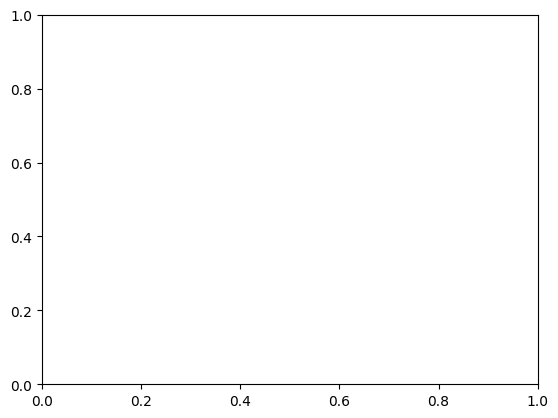

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.subplot()

In [5]:
import jax.numpy as jnp
import numpy as np 

from sklearn.datasets import fetch_20newsgroups

import matplotlib.pyplot as plt
import seaborn as sns

from cartm.model import ContextTopicModel
from cartm.preprocessing import DatasetPreprocessor

This example will guide you through the basic interaction with the model.

## Data preprocessing

First, let's download a sample dataset and preprocess it with `DatasetPreprocessor`.

In [7]:
data = fetch_20newsgroups(data_home='./data/', subset='all').data
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 18846
Total number of words in corpus: 5937230


In [6]:
with open('./data/test_data.txt') as f:
    data = f.readlines()
print(f'Total number of documents in corpus: {len(data)}')
print(f'Total number of words in corpus: {sum([len(doc.split(" ")) for doc in data])}')

Total number of documents in corpus: 4
Total number of words in corpus: 34


In [8]:
preprocessor = DatasetPreprocessor()
tokenized_data, document_bounds = preprocessor.fit_transform(data)
print(f'Total number of document boundaries in preprocessed corpus: {len(document_bounds)}')
print(f'Total number of tokenized words in preprocessed corpus: {len(tokenized_data)}')

E0402 19:19:04.255473   20664 cuda_executor.cc:1743] Could not get kernel mode driver version: [INVALID_ARGUMENT: Version does not match the format X.Y.Z]
E0402 19:19:04.267860    1548 cuda_executor.cc:1743] Could not get kernel mode driver version: [INVALID_ARGUMENT: Version does not match the format X.Y.Z]


Total number of document boundaries in preprocessed corpus: 18847
Total number of tokenized words in preprocessed corpus: 3005990


The `DatasetPreprocessor` class handles the filtering and tokenizing of the raw data. Its method `fit_transform` learns the vocabulary of the passed corpus of documents and returns tokenized words from corpus as the first return value, and document bounds as the second return value.

By default, `DatasetPreprocessor` removes stopwords, digits and special characters, therefore the total number of tokenized words is less than the number of words in raw corpus. Document boundaries are at the beginning and ending of the document, therefore the number of boundaries is [number_of_documents] + 1.

The returned values from `fit_transform` have jax.numpy.ndarray type, so you can work with them like a normal arrays.

In [9]:
print(f'Number of unique words in the preprocessed corpus: {jnp.max(tokenized_data)}')

Number of unique words in the preprocessed corpus: 90681


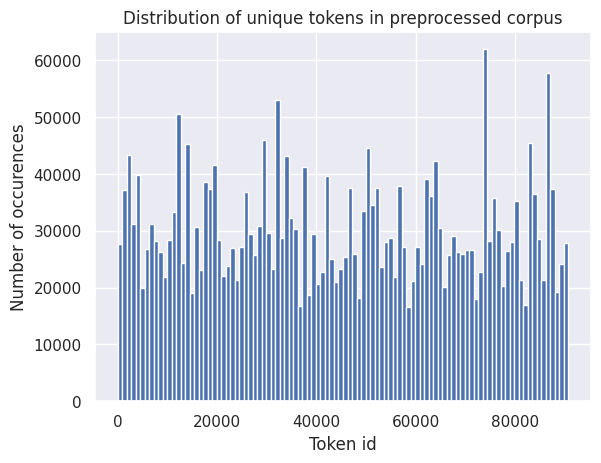

In [10]:
sns.set_theme()

plt.hist(tokenized_data, bins=100)

plt.xlabel('Token id')
plt.ylabel('Number of occurences')
plt.title('Distribution of unique tokens in preprocessed corpus')
#plt.yscale('log')
plt.show()

### Accessing vocabulary

You can also access mapping of words to tokens after fitting the preprocessor with data.

In [11]:
vocabulary = preprocessor.vocabulary

for i, (word, token) in enumerate(vocabulary.items()):
    print(f'{word}: {token}')
    if i == 10:
        break

reverse_vocab = {value: key for key, value in vocabulary.items()}
[reverse_vocab[t] for t in tokenized_data.tolist()]

koennten: 0
woodcock: 1
ugpmyg: 2
fbg: 3
jrv: 4
dxtlp: 5
kku: 6
earl: 7
iannelli: 8
hampshir: 9
chalki: 10


['mamatha',
 'devineni',
 'ratnam',
 'andrew',
 'cmu',
 'edu',
 'subject',
 'pen',
 'fan',
 'reaction',
 'organ',
 'post',
 'offic',
 'carnegi',
 'mellon',
 'pittsburgh',
 'line',
 'nntp',
 'post',
 'host',
 'andrew',
 'cmu',
 'edu',
 'sure',
 'basher',
 'pen',
 'fan',
 'pretti',
 'confus',
 'lack',
 'kind',
 'post',
 'recent',
 'pen',
 'massacr',
 'devil',
 'actual',
 'bit',
 'puzzl',
 'bit',
 'reliev',
 'howev',
 'go',
 'put',
 'end',
 'non',
 'pittsburgh',
 'relief',
 'bit',
 'prais',
 'pen',
 'man',
 'kill',
 'devil',
 'wors',
 'thought',
 'jagr',
 'show',
 'much',
 'better',
 'regular',
 'season',
 'stat',
 'also',
 'lot',
 'fun',
 'watch',
 'playoff',
 'bowman',
 'let',
 'jagr',
 'lot',
 'fun',
 'next',
 'coupl',
 'game',
 'sinc',
 'pen',
 'go',
 'beat',
 'pulp',
 'jersey',
 'anyway',
 'disappoint',
 'see',
 'island',
 'lose',
 'final',
 'regular',
 'season',
 'game',
 'pen',
 'rule',
 'mblawson',
 'midway',
 'ecn',
 'uoknor',
 'edu',
 'matthew',
 'lawson',
 'subject',
 'high',
 

## Model training

Having the data preprocessed with `DatasetPreprocessor`, we can fit out model pretty straighforwardly.

Please note that calling `fit` method multiple times in one model will discard all results of the previous training.

In [12]:
%load_ext autoreload
%autoreload 2

In [24]:
from cartm.model import ContextTopicModel

topic_model = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=10
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

start model
Iteration [1/1000], _phi update diff norm: 0.1118
Iteration [2/1000], _phi update diff norm: 0.0068
Iteration [3/1000], _phi update diff norm: 0.0098
Iteration [4/1000], _phi update diff norm: 0.0134
Iteration [5/1000], _phi update diff norm: 0.0159
Iteration [6/1000], _phi update diff norm: 0.0180
Iteration [7/1000], _phi update diff norm: 0.0209
Iteration [8/1000], _phi update diff norm: 0.0236
Iteration [9/1000], _phi update diff norm: 0.0255
Iteration [10/1000], _phi update diff norm: 0.0261
Iteration [11/1000], _phi update diff norm: 0.0250
Iteration [12/1000], _phi update diff norm: 0.0221
Iteration [13/1000], _phi update diff norm: 0.0183
Iteration [14/1000], _phi update diff norm: 0.0150
Iteration [15/1000], _phi update diff norm: 0.0127
Iteration [16/1000], _phi update diff norm: 0.0112
Iteration [17/1000], _phi update diff norm: 0.0102
Iteration [18/1000], _phi update diff norm: 0.0096
Iteration [19/1000], _phi update diff norm: 0.0089
Iteration [20/1000], _phi up

In [16]:
from cartm.experimental_model import ExperimentalContextTopicModel

topic_model = ExperimentalContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
    n_topics=20
)

topic_model.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    verbose=2,
    seed=42,
)

start experimantal_model
Iteration [1/1000], _phi update diff norm: 0.1585
Iteration [2/1000], _phi update diff norm: 0.0109
Iteration [3/1000], _phi update diff norm: 0.0160
Iteration [4/1000], _phi update diff norm: 0.0235
Iteration [5/1000], _phi update diff norm: 0.0337
Iteration [6/1000], _phi update diff norm: 0.0446
Iteration [7/1000], _phi update diff norm: 0.0490
Iteration [8/1000], _phi update diff norm: 0.0449
Iteration [9/1000], _phi update diff norm: 0.0404
Iteration [10/1000], _phi update diff norm: 0.0366
Iteration [11/1000], _phi update diff norm: 0.0323
Iteration [12/1000], _phi update diff norm: 0.0282
Iteration [13/1000], _phi update diff norm: 0.0240
Iteration [14/1000], _phi update diff norm: 0.0220
Iteration [15/1000], _phi update diff norm: 0.0211
Iteration [16/1000], _phi update diff norm: 0.0206
Iteration [17/1000], _phi update diff norm: 0.0200
Iteration [18/1000], _phi update diff norm: 0.0191
Iteration [19/1000], _phi update diff norm: 0.0177
Iteration [20/1

The model training stops because the update diff norm becomes too low. This means that the model has converged. You can modify the convergence threshold and max number of iterations.

In [17]:
topic_model_tol = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)

topic_model_tol.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    tol=0.01,
    verbose=2,
    seed=42,
)

start model
Iteration [1/1000], _phi update diff norm: 0.1118
Iteration [2/1000], _phi update diff norm: 0.0068
Время выполнения 2.3903634548187256


In [18]:
topic_model_iter = ContextTopicModel(
    vocab_size=len(preprocessor.vocabulary),
    ctx_len=10,
)

topic_model_iter.fit(
    data=tokenized_data,
    ctx_bounds=document_bounds,
    max_iter=10,
    verbose=2,
    seed=42,
)

start model
Iteration [1/10], _phi update diff norm: 0.1118
Iteration [2/10], _phi update diff norm: 0.0068
Iteration [3/10], _phi update diff norm: 0.0098
Iteration [4/10], _phi update diff norm: 0.0134
Iteration [5/10], _phi update diff norm: 0.0159
Iteration [6/10], _phi update diff norm: 0.0180
Iteration [7/10], _phi update diff norm: 0.0209
Iteration [8/10], _phi update diff norm: 0.0236
Iteration [9/10], _phi update diff norm: 0.0255
Iteration [10/10], _phi update diff norm: 0.0261
Время выполнения 1.813549518585205


You can also modify number of topics and other parameters of the model. Refer to the `fit` funciton docs for more info about model training.

## Analysis

After the model is fitted, you can access its parameters and analyse them.

In [19]:
phi_wt = topic_model.phi  # p(w|t)
n_t = topic_model.n_t  # denormalized distribution of topics
print(f'phi matrix type: {type(phi_wt)}, shape: {phi_wt.shape}')
print(f'n_t array type: {type(n_t)}, shape: {n_t.shape}')

phi matrix type: <class 'jaxlib._jax.ArrayImpl'>, shape: (90682, 20)
n_t array type: <class 'jaxlib._jax.ArrayImpl'>, shape: (20,)


### Plot a histogram of a distribution of topics in corpus:

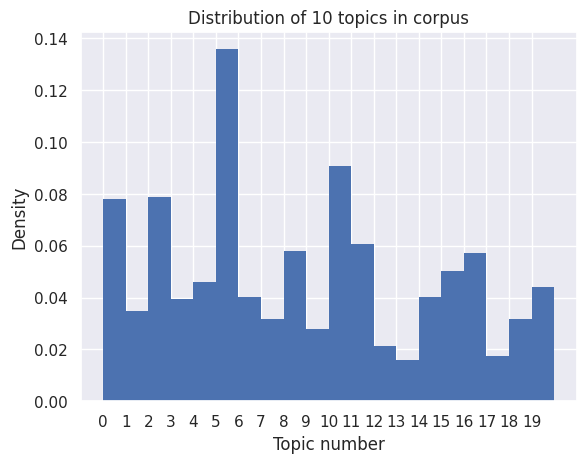

In [20]:
plt.stairs(n_t / n_t.sum(), range(len(n_t) + 1), fill=True)

plt.xticks(range(len(n_t)))
plt.xlabel('Topic number')
plt.ylabel('Density')
plt.title('Distribution of 10 topics in corpus')
plt.show()

### Print top-10 words from each topic:

In [21]:
# find top-10 words with the biggest probability p(w|t) for each topic t
topk = jnp.argsort(phi_wt, axis=0, descending=True)[:20, :].T

# create mapping token -> word from existing mapping word -> token (vocabulary)
reverse_vocab = {value: key for key, value in vocabulary.items()}

for topic_idx, t in enumerate(topk):
    print(f'Topic {topic_idx + 1}:', '\t'.join([reverse_vocab[int(idx)] for idx in t]))
    print()

Topic 1: car	back	get	around	one	light	put	start	left	away	head	bike	fire	hand	turn	like	power	right	come	use

Topic 2: thank	anyon	question	know	pleas	help	read	ask	answer	would	post	someon	els	appreci	write	interest	inform	advanc	want	need

Topic 3: use	window	file	program	imag	run	do	bit	includ	system	applic	set	graphic	color	display	data	also	format	code	packag

Topic 4: com	subject	write	org	netcom	ibm	organ	jim	david	att	mark	sun	repli	dave	appl	sgi	stratu	articl	ray	dec

Topic 5: year	time	day	last	one	first	two	second	everi	week	long	old	three	month	ago	next	night	sever	hour	coupl

Topic 6: would	like	one	think	get	know	make	peopl	thing	good	could	way	much	well	want	say	see	even	someth	seem

Topic 7: game	team	play	player	win	hockey	fan	season	score	subject	basebal	red	leagu	goal	frank	nhl	playoff	blue	uni	cup

Topic 8: key	access	public	system	encrypt	softwar	chip	commun	servic	organ	opinion	net	clipper	phone	secur	use	unix	user	inform	news

Topic 9: use	drive	card	version	sys

In [ ]:
[reverse_vocab[i] for i in reverse_vocab if len(reverse_vocab[i]) == 2]

In [6]:
voc = preprocessor.vocabulary

In [22]:
[1.0, ] + 

[1.0]